In [2]:
import pandas as pd
import plotly.express as px
from datetime import datetime
import pytz

In [3]:
# Load Playstore dataset
apps = pd.read_csv(r"C:\Users\vanda\Downloads\Play Store Data.csv")
apps.head()          

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
# Load user reviews dataset
reviews = pd.read_csv(r"C:\Users\vanda\Downloads\User Reviews.csv")
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
# Data Cleaning
apps["Installs"] =(apps["Installs"].astype(str).str.replace(",","",regex = False).str.replace("+","",regex = False))

In [6]:
apps["Installs"] = pd.to_numeric(apps["Installs"],errors = "coerce")

In [7]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"],errors = "coerce")

In [8]:
apps["Rating"] = pd.to_numeric(apps["Rating"],errors = "coerce")

In [9]:
# Convert size to MB
def convert_size(x):
    if pd.isna(x):
        return None
    x = str(x)
    if "M" in x:
        return float(x.replace("M",""))
    elif "K" in x:
        return float(x.replace("K",""))/1024
    else:
        return None

In [10]:
apps["Size_MB"] = apps["Size"].apply(convert_size)

In [11]:
apps["Size_MB"] = pd.to_numeric(apps["Size_MB"],errors = "coerce")

In [12]:
reviews['Sentiment_Subjectivity'] = pd.to_numeric(reviews['Sentiment_Subjectivity'],errors = "coerce")

In [13]:
# Average Sentiment Subjectivity
subjectivity = reviews.groupby("App",as_index = False)['Sentiment_Subjectivity'].mean()

In [14]:
# Merge
apps = pd.merge(apps,subjectivity,on = "App",how = "inner")

In [15]:
# Required Categories
categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENT"]
    

In [16]:
# Filtering Data
apps = apps[
    (apps["Rating"] > 3.5) &
    (apps["Category"].isin(categories)) &
    (apps["Reviews"] > 500) &
    (~apps["App"].str.contains("S",case = False,na = False)) &
    (apps['Sentiment_Subjectivity'] > 0.5) &
    (apps["Installs"] > 50000)
    ]

In [17]:
# Category Translation
category_translation = {
    "BEAUTY" : "सौंदर्य", # Hindi
    "BUSINESS" : "வியாபாரம்", # Tamil
    "DATING" : "Partnersuche" } # German

In [18]:
apps["Category_Display"] = apps["Category"].replace(category_translation )

In [19]:
# Current Time(IST)
#ist = pytz.timezone("Asia/Kolkata")
#current_time = datetime.now(ist).time()

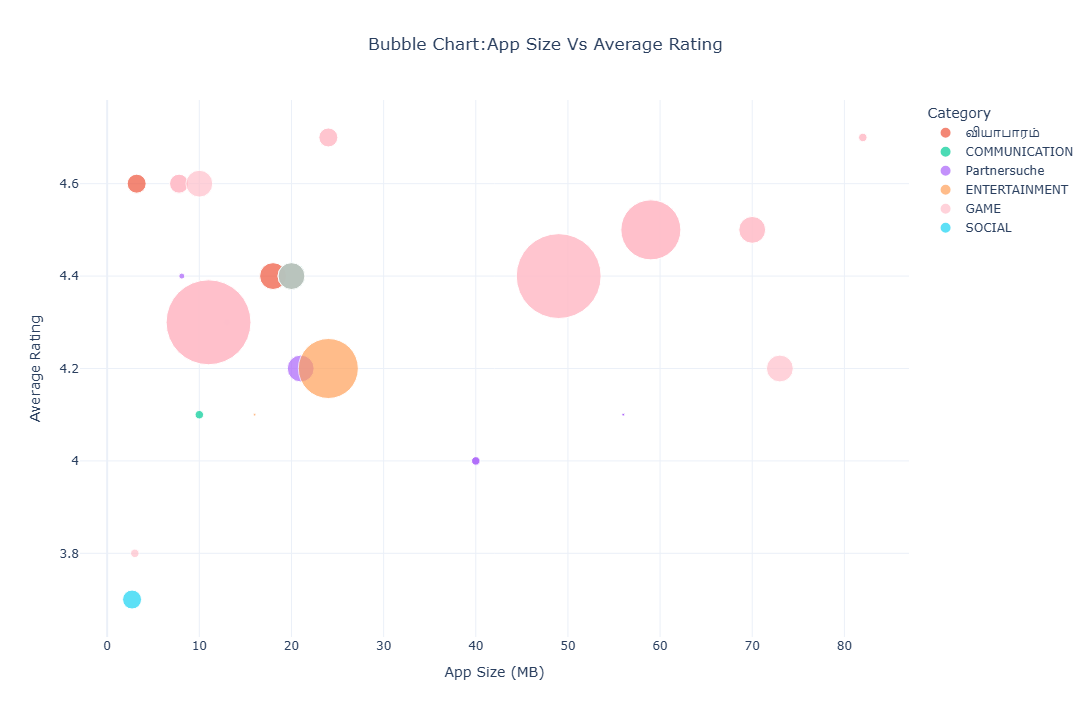

In [22]:
# Show graph only between 5 PM and 7 PM
#start = datetime.strptime("17:00","%H:%M").time() 
#end = datetime.strptime("19:00","%H:%M").time()
#if start <= current_time <= end:
    
    # Bubble Chart
fig = px.scatter(
        apps,
        x = "Size_MB",
        y = "Rating",
        size = "Installs",
        color = "Category_Display",
        hover_name = "App",
        hover_data = ["Category_Display","Installs"],
        size_max = 60,
        color_discrete_map = {"GAME":"pink"},
        title = "Bubble Chart:App Size Vs Average Rating",
        labels = {
            "Category_Display":"Category"
        }
    )
    
fig.update_traces(marker=dict(opacity=0.7))
    
fig.update_layout(
        xaxis_title = "App Size (MB)",
        yaxis_title = "Average Rating",
        template = "plotly_white",
        title_x = 0.5,
        height = 700,
        width = 1200
    )
    
fig.show()
    
#else:
   #print("Bubble Chart is available only between 5 PM IST and 7 PM IST")


In [21]:
# CONCLUSION
#The bubble chart was successfully created to analyze the relationship between App Size (MB) and Average Rating, 
#with bubble size representingthe number of installs. The visualization was generated after applying all the required filters, 
#including rating greater than 3.5, reviews above 500, installs greater than 50,000, sentiment subjectivity above 0.5, and 
#the specified app categories. Apps containing the letter "S" in their names were excluded. The Game category was highlighted in pink, and 
#the category names were translated as required (Beauty → सौंदर्य, Business → வணிகம், Dating → Partnersuche). 
#**The dashboard also includes a time-based condition so that the chart is displayed only between 5:00 PM IST and 7:00 PM IST. 
#**This visualization effectively demonstrates the relationship between app size, user ratings, and installs while meeting all the specified assignment requirements.